# Predicción poblacional utilizando Regresión polinómica

Este notebook explica paso a paso cómo construir una **regresión polinómica** y entregar predicciones de población mediante un bot de Telegram, este modelo  utiliza un dataset llamado **World Population** para procesar datos demográficos históricos.

El enfoque principal será Colombia, pero la estructura quedará preparada para consultar otros países.

---

## Objetivo general

Crear un chatbot que:

1. Lea un dataset histórico de población mundial.
2. Procese y limpie los datos demográficos.
3. Modele la población histórica usando regresión polinómica.
4. Genere visualizaciones estadísticas dinámicas.
5. Entregue predicciones de población según país y año ingresado por el usuario.


## 1. Instalación de librerías necesarias

Para ejecutar este proyecto se necesitan las siguientes librerías:

- `pandas`: lectura y manipulación de datos.
- `numpy`: manejo numérico.
- `matplotlib`: generación de gráficos.
- `scikit-learn`: entrenamiento del modelo de regresión polinómica.

Ejecuta esta celda solo si estás en un entorno donde aún no tienes instaladas las dependencias.

In [ ]:
# Ejecutar solo si necesitas instalar dependencias
# !pip install pandas numpy matplotlib scikit-learn python-telegram-bot python-dotenv
%pip install pandas numpy matplotlib scikit-learn python-telegram-bot python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importar librerías

En esta sección importamos las librerías principales que usaremos para cargar el dataset, entrenar el modelo y crear gráficos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path

## 3. Cargar el dataset World Population

El archivo esperado se llama `world_population.csv`.

Este notebook intentará encontrarlo en dos ubicaciones comunes:

1. En la misma carpeta del notebook.
2. Dentro de una carpeta llamada `data/`.

La estructura típica del dataset contiene columnas como:

- `Country/Territory`
- `2022 Population`
- `2020 Population`
- `2015 Population`
- `2010 Population`
- `2000 Population`
- `1990 Population`
- `1980 Population`
- `1970 Population`

In [ ]:
possible_paths = [
    Path("world_population.csv"),
    Path("data/world_population.csv"),
    Path("/mnt/data/world_population.csv")
]

dataset_path = None
for path in possible_paths:
    if path.exists():
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError("No se encontró el archivo world_population.csv. Ubícalo junto al notebook o dentro de data/.")

print(f"Dataset encontrado en: {dataset_path}")
df = pd.read_csv(dataset_path)
df.head()

Dataset encontrado en: data\world_population.csv


,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


## 4. Explorar la estructura del dataset

Antes de entrenar un modelo, es importante revisar:

- Cantidad de filas y columnas.
- Nombres de columnas.
- Tipos de datos.
- Valores nulos.

In [ ]:
print("Filas y columnas:", df.shape)
print("Columnas:")
for column in df.columns:
    print("-", column)

print("Valores nulos por columna:")
print(df.isnull().sum())

Filas y columnas: (234, 17)
Columnas:
- Rank
- CCA3
- Country/Territory
- Capital
- Continent
- 2022 Population
- 2020 Population
- 2015 Population
- 2010 Population
- 2000 Population
- 1990 Population
- 1980 Population
- 1970 Population
- Area (km²)
- Density (per km²)
- Growth Rate
- World Population Percentage
Valores nulos por columna:
Rank                           0
CCA3                           0
Country/Territory              0
Capital                        0
Continent                      0
2022 Population                0
2020 Population                0
2015 Population                0
2010 Population                0
2000 Population                0
1990 Population                0
1980 Population                0
1970 Population                0
Area (km²)                     0
Density (per km²)              0
Growth Rate                    0
World Population Percentage    0
dtype: int64


## 5. Seleccionar las columnas históricas de población

El modelo necesita pares de datos en este formato:

```text
Año -> Población
```

Por eso identificamos las columnas que contienen población histórica y extraemos el año de cada columna.

In [ ]:
population_columns = [
    "1970 Population",
    "1980 Population",
    "1990 Population",
    "2000 Population",
    "2010 Population",
    "2015 Population",
    "2020 Population",
    "2022 Population",
]

years = np.array([int(col.split()[0]) for col in population_columns])

print("Columnas históricas:", population_columns)
print("Años:", years)

Columnas históricas: ['1970 Population', '1980 Population', '1990 Population', '2000 Population', '2010 Population', '2015 Population', '2020 Population', '2022 Population']
Años: [1970 1980 1990 2000 2010 2015 2020 2022]


## 6. Crear una función para obtener la serie histórica de un país

Esta función recibe el nombre de un país y devuelve una tabla con dos columnas:

- `year`
- `population`

La función será útil tanto para el análisis en notebook como para el chatbot de Telegram.

In [ ]:
def get_country_population_history(dataframe, country_name):
    """
    Retorna el histórico de población para un país específico.
    """
    country_data = dataframe[
        dataframe["Country/Territory"].str.lower() == country_name.lower()
    ]
    
    if country_data.empty:
        available_examples = dataframe["Country/Territory"].head(10).tolist()
        raise ValueError(
            f"No se encontró el país: {country_name}. "
            f"Ejemplos disponibles: {available_examples}"
        )
    
    row = country_data.iloc[0]
    populations = row[population_columns].values.astype(float)
    
    history = pd.DataFrame({
        "year": years,
        "population": populations
    })
    
    return history.sort_values("year")

colombia_history = get_country_population_history(df, "Colombia")
colombia_history

,year,population
0,1970,20905254.0
1,1980,26176195.0
2,1990,32601393.0
3,2000,39215135.0
4,2010,44816108.0
5,2015,47119728.0
6,2020,50930662.0
7,2022,51874024.0


## 7. Visualizar la población histórica de Colombia

Esta gráfica permite observar la tendencia de crecimiento poblacional de Colombia desde 1970 hasta 2022.

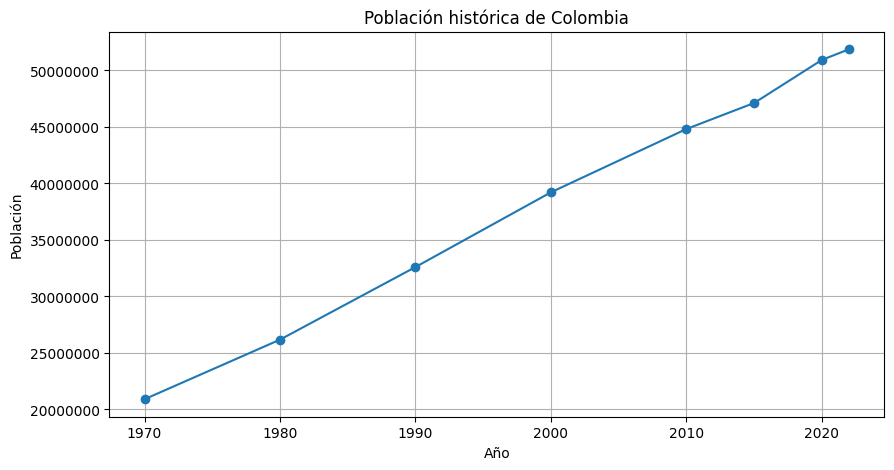

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(colombia_history["year"], colombia_history["population"], marker="o")
plt.title("Población histórica de Colombia")
plt.xlabel("Año")
plt.ylabel("Población")
plt.grid(True)
plt.ticklabel_format(style="plain", axis="y")
plt.show()

## 8. ¿Qué es la regresión polinómica?

La regresión polinómica es una técnica de Machine Learning usada para modelar relaciones no lineales.

En este caso, queremos aprender una función que relacione:

```text
Año -> Población estimada
```

Una regresión lineal simple puede quedarse corta si la población no crece de forma perfectamente recta. Por eso usamos características polinómicas, por ejemplo:

```text
población = b0 + b1*año + b2*año² + b3*año³
```

En este proyecto usaremos un modelo polinómico de grado 3.

## 9. Entrenar el modelo de regresión polinómica

Se usará un `Pipeline` de scikit-learn con dos pasos:

1. `PolynomialFeatures`: transforma el año en características polinómicas.
2. `LinearRegression`: entrena el modelo de regresión.

In [ ]:
def train_polynomial_model(history, degree=3):
    """
    Entrena un modelo de regresión polinómica para una serie histórica de población.
    """
    X = history[["year"]].values
    y = history["population"].values
    
    model = Pipeline([
        ("polynomial_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear_regression", LinearRegression())
    ])
    
    model.fit(X, y)
    predictions = model.predict(X)
    
    metrics = {
        "r2_score": r2_score(y, predictions),
        "mae": mean_absolute_error(y, predictions)
    }
    
    return model, metrics

model, metrics = train_polynomial_model(colombia_history, degree=3)
metrics

{'r2_score': 0.9989467719180651, 'mae': 287916.5850645602}

## 10. Interpretar las métricas del modelo

Las métricas principales son:

- **R² Score**: indica qué tan bien el modelo explica la variación de los datos. Mientras más cercano a 1, mejor ajuste.
- **MAE**: error absoluto medio. Indica, en promedio, cuántos habitantes se equivoca el modelo frente a los datos históricos.

Importante: un buen ajuste histórico no garantiza que la predicción futura sea perfecta. La población puede verse afectada por migración, economía, salud pública, política, natalidad, mortalidad y otros factores.

In [ ]:
print(f"R² Score: {metrics['r2_score']:.4f}")
print(f"Error absoluto medio MAE: {metrics['mae']:,.0f} habitantes")

R² Score: 0.9989
Error absoluto medio MAE: 287,917 habitantes


## 11. Generar predicciones futuras

Ahora creamos una función para predecir la población de un país en un año específico.

In [ ]:
def predict_population(dataframe, country_name, target_year, degree=3):
    """
    Entrena un modelo para el país indicado y predice la población en un año futuro.
    """
    history = get_country_population_history(dataframe, country_name)
    model, metrics = train_polynomial_model(history, degree=degree)
    
    prediction = model.predict(np.array([[target_year]]))[0]
    
    return {
        "country": country_name,
        "year": target_year,
        "prediction": max(0, prediction),
        "metrics": metrics,
        "history": history,
        "model": model
    }

result = predict_population(df, "Colombia", 2030)
print(f"Predicción para {result['country']} en {result['year']}: {result['prediction']:,.0f} habitantes")

Predicción para Colombia en 2030: 56,684,051 habitantes


## 12. Graficar histórico y predicción

Esta gráfica combina:

- Datos históricos reales.
- Curva del modelo polinómico.
- Punto de predicción futura.

Esta misma gráfica puede generarse en tiempo real y enviarse como imagen desde Telegram.

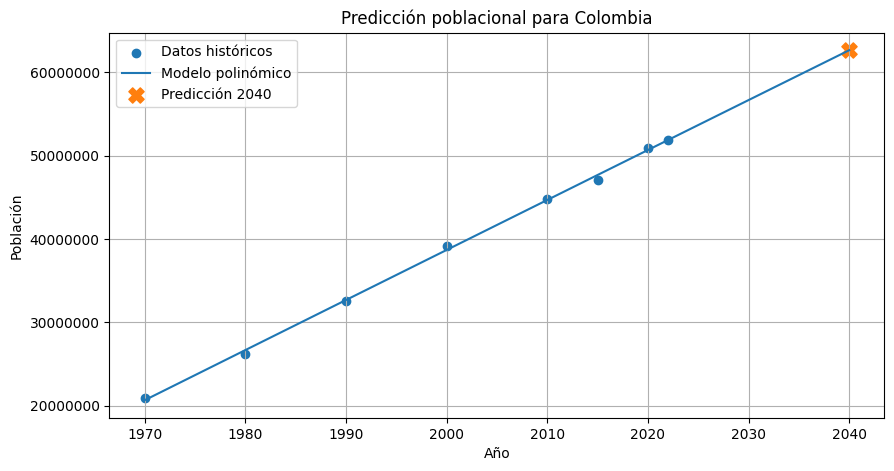

In [ ]:
def plot_country_prediction(dataframe, country_name, target_year, degree=3):
    result = predict_population(dataframe, country_name, target_year, degree)
    history = result["history"]
    model = result["model"]
    prediction = result["prediction"]
    
    min_year = int(history["year"].min())
    max_year = max(int(target_year), int(history["year"].max()))
    future_years = np.arange(min_year, max_year + 1).reshape(-1, 1)
    model_predictions = model.predict(future_years)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(history["year"], history["population"], label="Datos históricos")
    plt.plot(future_years.flatten(), model_predictions, label="Modelo polinómico")
    plt.scatter([target_year], [prediction], marker="X", s=120, label=f"Predicción {target_year}")
    
    plt.title(f"Predicción poblacional para {country_name}")
    plt.xlabel("Año")
    plt.ylabel("Población")
    plt.grid(True)
    plt.legend()
    plt.ticklabel_format(style="plain", axis="y")
    plt.show()
    
    return result

plot_result = plot_country_prediction(df, "Colombia", 2040)

## 13. Guardar la gráfica como imagen

Para Telegram no basta con mostrar la gráfica en pantalla. Es necesario guardarla como imagen para poder enviarla al usuario.

La siguiente función genera una imagen `.png` con la predicción.

In [ ]:
def save_country_prediction_chart(dataframe, country_name, target_year, output_path="prediction_chart.png", degree=3):
    result = predict_population(dataframe, country_name, target_year, degree)
    history = result["history"]
    model = result["model"]
    prediction = result["prediction"]
    
    min_year = int(history["year"].min())
    max_year = max(int(target_year), int(history["year"].max()))
    chart_years = np.arange(min_year, max_year + 1).reshape(-1, 1)
    model_predictions = model.predict(chart_years)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(history["year"], history["population"], label="Datos históricos")
    plt.plot(chart_years.flatten(), model_predictions, label="Modelo polinómico")
    plt.scatter([target_year], [prediction], marker="X", s=120, label=f"Predicción {target_year}")
    
    plt.title(f"Predicción poblacional para {country_name}")
    plt.xlabel("Año")
    plt.ylabel("Población")
    plt.grid(True)
    plt.legend()
    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()
    plt.savefig(output_path)
    plt.close()
    
    return output_path, result

image_path, prediction_result = save_country_prediction_chart(df, "Colombia", 2030)
print("Imagen generada:", image_path)
print(f"Predicción: {prediction_result['prediction']:,.0f} habitantes")

Imagen generada: prediction_chart.png
Predicción: 56,684,051 habitantes


## 14. Conclusión

Con este notebook se explicó cómo construir un chatbot poblacional con Python que integra:

- Procesamiento de datos demográficos históricos.
- Machine Learning mediante regresión polinómica.
- Visualizaciones estadísticas dinámicas.
- Predicciones por país y año.


Este proyecto es una base ideal para explicar conceptos de ciencia de datos, automatización, inteligencia artificial aplicada a datos poblacionales.